In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.032086,31.94222,21.142751,10.799469,3.280691,66.358427,1.593342,2.882003,96.492724,13.995392,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,20.610000,23.45000,12.260000,2.680000,0.000000,11.470000,0.370000,0.600000,95.970000,2.720000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,24.410000,28.90000,20.050000,6.980000,0.000000,50.080000,1.190000,2.200000,96.380000,10.280000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,25.590000,31.52500,21.630000,9.830000,0.510000,72.650000,1.550000,2.840000,96.500000,16.325000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.422500,34.86000,22.770000,14.812500,3.700000,85.322500,1.930000,3.480000,96.610000,17.360000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,33.040000,42.11000,27.260000,20.920000,130.170000,94.510000,4.790000,7.170000,96.940000,19.830000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,2.186667,3.68257,2.547927,4.471615,7.012564,21.400040,0.549888,0.917871,0.157852,4.364694,NaN,3.477046


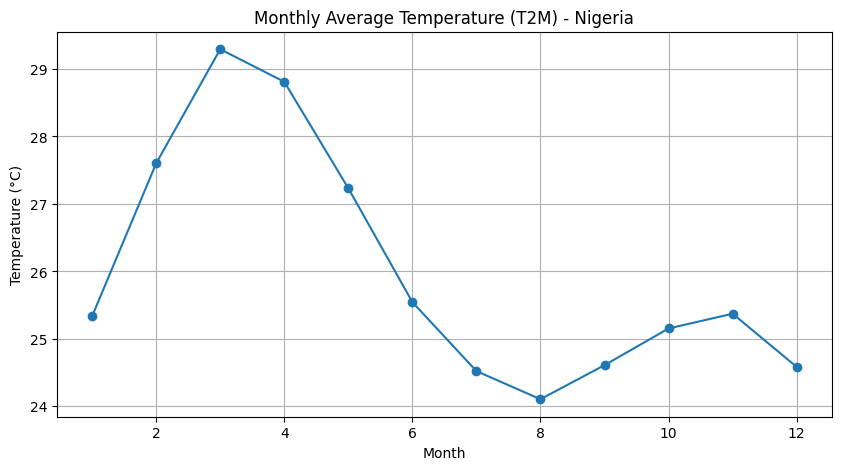

In [2]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Nigeria")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [3]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [4]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [5]:
high_missing = missing_pct[missing_pct > 5]
high_missing


Series([], dtype: float64)

In [6]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.440032,0.694648,-1.598651,-0.467887,-1.590771,0.957872,0.967570
1,-0.732750,0.805997,-1.959773,-0.467887,-1.721161,1.576255,1.523272
2,-0.828799,0.865745,-1.916595,-0.467887,-1.902491,3.722409,3.212168
3,-1.153533,0.697364,-2.269867,-0.467887,-1.967919,3.977037,3.626220
4,-1.382220,0.319865,-2.332670,-0.467887,-1.800610,1.576255,1.643129


In [7]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

In [8]:
df.to_csv("../data/nigeria_clean.csv", index=False)

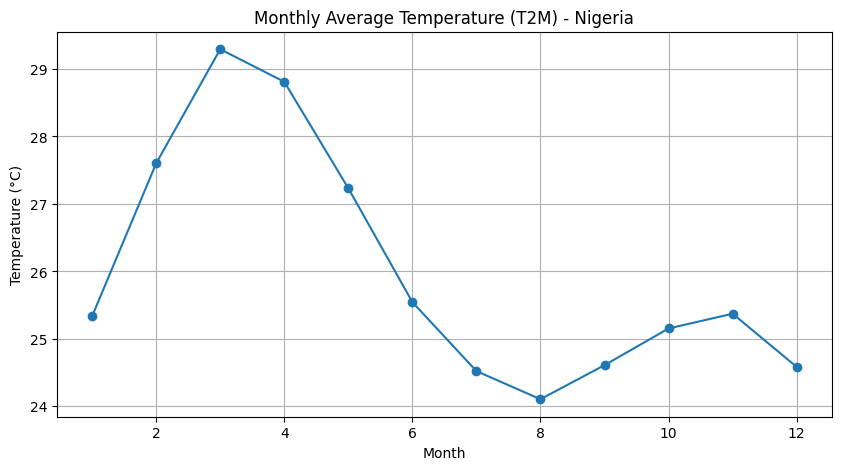

In [9]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Nigeria")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

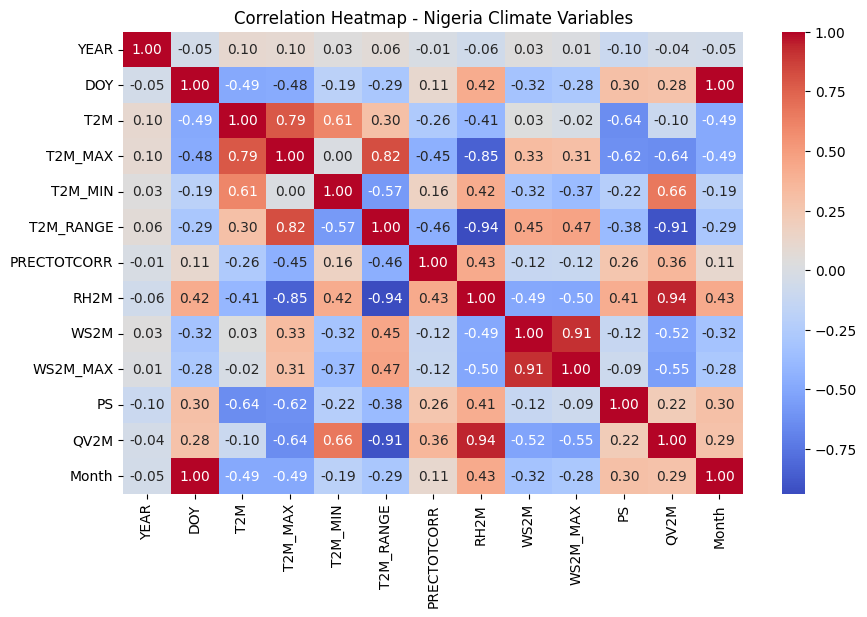

In [10]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Nigeria Climate Variables")
plt.show()

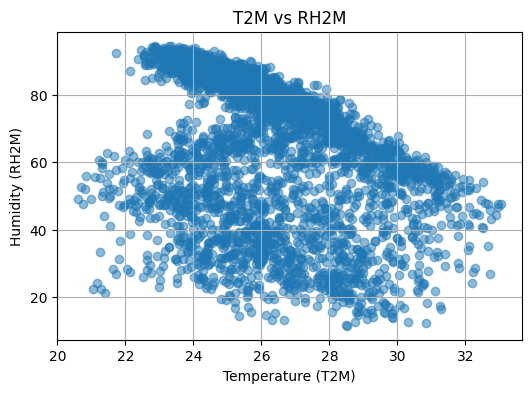

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

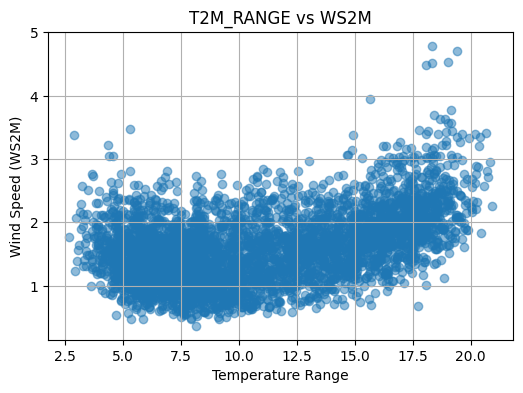

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [13]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY    Month    0.996557
Month  DOY      0.996557
QV2M   RH2M     0.943885
dtype: float64

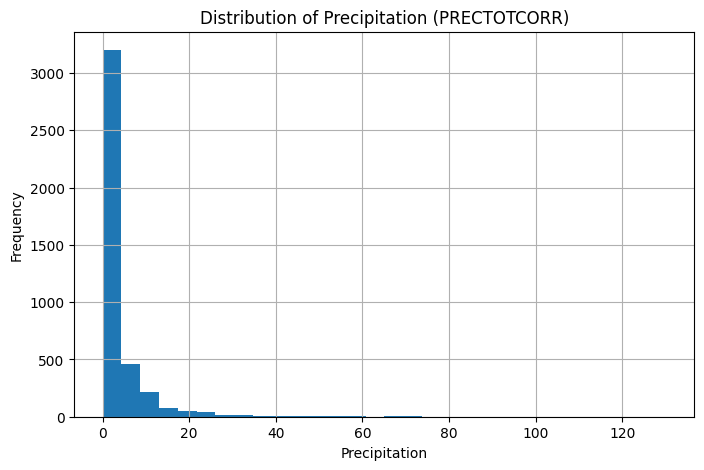

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

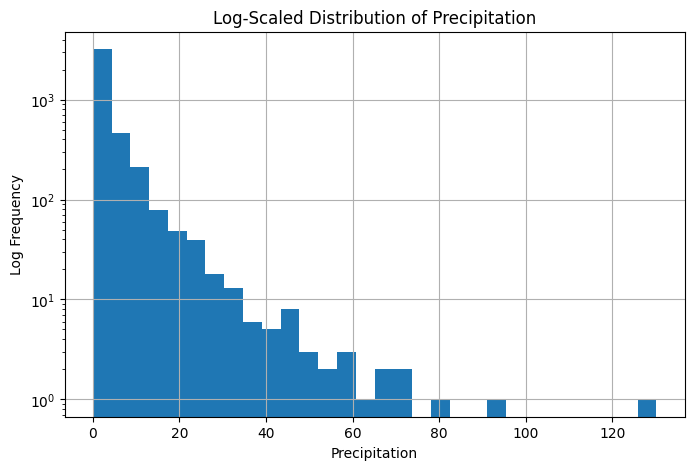

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

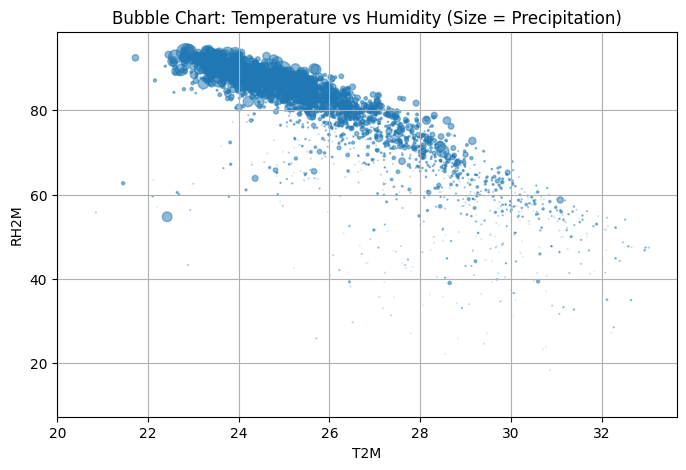

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()